### Enable importing modules from the parent project directory

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))  # Adds project root

### Importing necessary libraries

In [ ]:
import pandas as pd  # Data manipulation and DataFrame support
import numpy as np  # Numerical computing with arrays
import math  # Basic mathematical functions
import matplotlib.pyplot as plt  # Plotting and visualization
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Evaluation metrics
from statistics import mode  # Compute statistical mode
import folium  # Interactive maps (leaflet.js-based)
from folium.plugins import MarkerCluster  # Cluster markers on maps
from scipy.stats import pearsonr  # Pearson correlation calculation
from sklearn.preprocessing import StandardScaler  # Z-score normalization
from sklearn.preprocessing import MinMaxScaler  # Scale features to 0–1 range
from tqdm import tqdm  # Progress bars for loops
from prophet import Prophet  # Facebook Prophet time series forecasting
import random  # Random number generation
from sklearn.impute import SimpleImputer  # Basic missing value imputation
from typing import Dict  # Type hinting for dictionaries
import seaborn as sns  # Statistical data visualization
from sklearn.impute import SimpleImputer  # (Duplicate) Basic imputation again
from IPython.display import display, HTML  # Pretty HTML display in notebooks
from sklearn.decomposition import PCA  # Principal Component Analysis (dimensionality reduction)
from sklearn.preprocessing import StandardScaler  # (Duplicate) Z-score scaling
from statsmodels.tsa.holtwinters import ExponentialSmoothing  # Time series smoothing & forecasting
from sklearn.ensemble import RandomForestRegressor  # Random Forest for regression tasks
from sklearn.inspection import permutation_importance  # Feature importance via permutation
import warnings  # Control warning messages
warnings.filterwarnings("ignore")  # Suppress warnings (useful in notebooks)
from prophet.plot import plot_plotly, plot_components_plotly  # Plotting Prophet results
from prophet.diagnostics import cross_validation, performance_metrics  # Prophet diagnostics tools

In [ ]:
from typing import List, Tuple  # Type hinting for lists and tuples

from Algorithms.CDREC import CDRec  # Collaborative Denoising for matrix completion
from Algorithms.TKCM import TKCM  # Top-k Case Matching (basic version)
from Algorithms.TKCM_Weighted import TKCM_Weighted  # TKCM with similarity-based weighting
from Algorithms.DynaMMO import DynaMMo  # Dynamic Matrix Modeling for time series imputation
from Algorithms.SoftImpute import SoftImpute  # Low-rank matrix completion using soft-thresholding
from Algorithms.SVDImpute import IterativeSVD  # Iterative SVD-based matrix imputation
from Algorithms.trmf import TRMFImputer  # Temporal Regularized Matrix Factorization
from Algorithms.ST_MVL import ST_MVL  # Space-Time Matrix-Vector Learning
from Algorithms.TKCM_PLUS import TKCM_PLUS  # TKCM variant with alpha–beta blending, also using Target series known values to fill the missing values
from Algorithms.TKCM_PRO import TKCM_PRO  # Pro version of TKCM with anchor filtering, here averaging the refrence to fill the missing values


### Loading the Dataset

In [4]:

# # Load dataset
valley_df = pd.read_csv("D:\\Thesis\\Project\\Data\\valley_data.csv")

# Count different types of missingness
stats = {
    "Total Rows": len(valley_df),
    "Total Columns": len(valley_df.columns),
    "Zero Values": (valley_df == 0).sum().sum(),
    "NaN Values": valley_df.isna().sum().sum(),
    "Blank Strings": (valley_df == "").sum().sum(),
    "Unknown Strings": (valley_df.applymap(lambda x: isinstance(x, str) and x.strip().lower() == "unknown")).sum().sum()
}

# Return as DataFrame
stats_df = pd.DataFrame(list(stats.items()), columns=["Metric", "Value"])
stats_df


,Metric,Value
0,Total Rows,7079427
1,Total Columns,6
2,Zero Values,1667902
3,NaN Values,0
4,Blank Strings,0
5,Unknown Strings,0


#### Displaying the first 5 rows of the data

In [5]:
valley_df.head()

,station_code,sensor_code,description_it,unit,timestamp,value
0,37100MS,LT,Temperatura dell´aria,°C,2025-01-01 00:00:00,-10.4
1,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:30:00,-8.9
2,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 23:00:00,-9.5
3,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:30:00,-8.1
4,37100MS,LT,Temperatura dell´aria,°C,2024-12-31 22:00:00,-8.8


### Displaying column-wise metadata


In [6]:
valley_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7079427 entries, 0 to 7079426
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   station_code    object 
 1   sensor_code     object 
 2   description_it  object 
 3   unit            object 
 4   timestamp       object 
 5   value           float64
dtypes: float64(1), object(5)
memory usage: 324.1+ MB


### describe() provide us with statistical summary of numeric columns

In [7]:
valley_df.describe()

,value
count,7.079427e+06
mean,1.722966e+02
std,3.336668e+02
min,-9.760000e+01
25%,0.000000e+00
50%,3.600000e+00
75%,1.000000e+02
max,1.474800e+03


In [8]:
# Preview data
print("🔍 Shape:", valley_df.shape)

🔍 Shape: (7079427, 6)


In [9]:
# Check which columns are non-numeric
print("🧠 Columns in the file:\n", valley_df.dtypes)

🧠 Columns in the file:
 station_code       object
sensor_code        object
description_it     object
unit               object
timestamp          object
value             float64
dtype: object


### Checking all the unique sensor codes i have in this dataset

In [10]:
unique_values = valley_df['sensor_code'].unique()
unique_values

array(['LT', 'N', 'WR', 'WG', 'WG.BOE', 'LF', 'LD.RED', 'GS', 'SD', 'HS',
       'W', 'WT'], dtype=object)

### checking unique similar station_codes

In [11]:
unique_values1 = valley_df['station_code'].unique()
unique_values1

array(['37100MS', '20500MS', '19300MS', '80300MS', '50500MS', '34500MS',
       '56900MS', '54500MS', '69900MS', '09700MS', '82200MS', '88820MS',
       '59700MS', '85120MS', '83200MS', '86900MS', '39100MS', '08200MS',
       '23200MS', '47400MS', '86600MS', '37700MS', '74900MS', '89190MS',
       '22210MS', '25900MS', '73500MS', '68600MS', '02200MS', '03100MS',
       '41000MS', '75600MS', '62600MS', '74200MS', '11400MS', '02500MS',
       '33500MS', '44500MS', '06400MS', '65600MS', '24400MS', '43200MS',
       '78305MS', '56500MS', '42700MS', '15800MS', '65350MS', '89950SE',
       '02250SE', '78150SE', '82910MS', '47150SE', '27100MS', '89155SE',
       '89355SE', '85700MS', '89055SE', '42150SE', '39050SE', '79450SE',
       '87300MS', '66500MS', '20910MS', '31410MS', '78110MS', '61300MS',
       '01110MS', '71510MS', '79300MS', '75510SE', '90150SE', '91510MS'],
      dtype=object)

### Looking at the descriptions of the sensor what is meaning of those sensor codes

In [12]:
unique_values2 = valley_df['description_it'].unique()
unique_values2

array(['Temperatura dell´aria', 'Precipitazioni', 'Direzione del vento',
       'Velocità del vento', 'Velocitá raffica', 'Umidità relativa',
       'Pressione atmosferica', 'Radiazione globale ',
       'Durata soleggiamento', 'Altezza neve al suolo',
       'Livello idrometrico', 'Temperatura acqua'], dtype=object)

### checking unit of data values

In [13]:
unique_values3 = valley_df['unit'].unique()
unique_values3

array(['°C', 'mm', '° ', 'm/s', '%', 'hPa', 'W/m²', 's', 'cm'],
      dtype=object)

### looking at unique values

In [14]:
unique_values4 = valley_df['value'].unique()
unique_values4

array([-10.4,  -8.9,  -9.5, ..., 981.9, 855.3, 802.7], shape=(11245,))

### Checking the columns i have and how they pronounced

In [15]:
column_names = list(valley_df.columns)
column_names

['station_code', 'sensor_code', 'description_it', 'unit', 'timestamp', 'value']

### counting the zeroes and sum them 

In [16]:
zero_counts = (valley_df == 0).sum()
print(zero_counts)

station_code            0
sensor_code             0
description_it          0
unit                    0
timestamp               0
value             1667902
dtype: int64


### displaying the values with zeroes

In [17]:
valley_df[valley_df["value"] == 0].head()

,station_code,sensor_code,description_it,unit,timestamp,value
116,37100MS,LT,Temperatura dell´aria,°C,2024-12-29 14:00:00,0.0
338,37100MS,LT,Temperatura dell´aria,°C,2024-12-24 23:00:00,0.0
426,37100MS,LT,Temperatura dell´aria,°C,2024-12-23 03:00:00,0.0
598,37100MS,LT,Temperatura dell´aria,°C,2024-12-19 13:00:00,0.0
637,37100MS,LT,Temperatura dell´aria,°C,2024-12-18 17:30:00,0.0


#### checking if values are numeric, if yes then add percentage to the zeroes and sort them by percentage of zero they contain. 

In [18]:
# Make sure 'value' is numeric
valley_df['value'] = pd.to_numeric(valley_df['value'], errors='coerce')

# Group by sensor_code
zero_stats = (
    valley_df.groupby('sensor_code')
    .agg(
        total_entries=('value', 'count'),
        zero_count=('value', lambda x: (x == 0).sum())
    )
)

# Add percentage of zeros
zero_stats['zero_percentage'] = (zero_stats['zero_count'] / zero_stats['total_entries']) * 100

# Sort by percentage of zero values
zero_stats = zero_stats.sort_values(by='zero_percentage', ascending=False)

print(zero_stats.reset_index())


   sensor_code  total_entries  zero_count  zero_percentage
0            N         585918      565938        96.589967
1           SD         773271      643102        83.166445
2           GS         758400      438331        57.796809
3            W          83263        5222         6.271693
4           LT         889920        7619         0.856144
5           WG         713371        4772         0.668937
6           HS          29182         170         0.582551
7       WG.BOE         713371        2423         0.339655
8           WT          83262          60         0.072062
9           WR         713371         265         0.037148
10          LF         875328           0         0.000000
11      LD.RED         860770           0         0.000000


In [19]:
# Step 1: Select sensor `LF`
lf_df = valley_df[valley_df['sensor_code'] == 'LF'].copy()

In [20]:
# Step 2: Replace `0.0` values with NaN
lf_df.loc[lf_df['value'] == 0.0, 'value'] = np.nan

In [21]:
# Step 3: Pivot to wide format (timestamp × station_code)
lf_df['timestamp'] = pd.to_datetime(lf_df['timestamp'])
pivot_df = lf_df.pivot(index='timestamp', columns='station_code', values='value')

In [22]:
# Step 4: Drop sparse stations (>10% missing)
threshold = 0.9 * len(pivot_df)
pivot_df = pivot_df.dropna(thresh=threshold, axis=1)

In [23]:
# Step 5: Drop rows with any missing values
clean_df = pivot_df.dropna(axis=0)

#### Displaying the clean dataframe to check what i have with me.

In [24]:
clean_df

station_code,01110MS,02200MS,02500MS,03100MS,06400MS,08200MS,09700MS,11400MS,15800MS,19300MS,...,82910MS,83200MS,85120MS,85700MS,86600MS,86900MS,87300MS,88820MS,89190MS,91510MS
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,99.1,90.4,82.5,86.2,94.8,99.8,92.7,91.6,91.9,90.6,...,93.8,87.7,99.9,96.8,95.8,98.1,97.6,83.5,84.3,99.9
2023-01-01 00:30:00,98.1,90.8,80.8,84.9,97.1,99.8,91.1,92.1,92.7,91.7,...,91.8,87.0,99.9,97.7,94.5,97.0,97.5,82.7,84.3,99.9
2023-01-01 01:00:00,98.0,91.5,81.9,83.5,96.7,99.8,90.0,89.1,92.4,90.1,...,92.1,85.3,99.9,97.1,93.5,98.5,99.7,89.8,81.3,99.9
2023-01-01 01:30:00,99.7,92.6,81.1,85.3,97.7,99.8,89.4,88.5,93.3,89.2,...,95.1,84.2,99.9,98.8,92.5,99.2,96.4,90.6,83.9,99.9
2023-01-01 02:00:00,99.8,94.2,81.9,84.5,95.4,99.8,88.2,86.2,94.2,89.1,...,98.6,88.4,99.9,99.6,94.5,99.0,99.9,90.0,80.9,99.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 22:00:00,54.5,74.4,38.3,53.7,48.4,91.3,64.9,51.1,49.7,89.4,...,84.0,90.2,47.1,100.2,99.6,98.7,53.8,95.8,64.1,96.9
2024-12-31 22:30:00,54.7,75.9,41.8,56.0,46.0,91.3,67.3,51.9,50.2,90.5,...,84.5,88.9,48.7,100.2,99.1,100.0,54.0,99.0,61.4,96.0
2024-12-31 23:00:00,54.7,77.3,39.0,55.8,46.4,92.2,64.2,51.1,51.0,90.4,...,85.7,89.0,48.4,99.7,99.7,100.0,57.7,96.6,63.5,96.1


In [25]:
# Step 6: Pick a target station (first available column)
target_station = clean_df.columns[2]

#### displaying target station

In [26]:
target_station

'02500MS'

In [27]:
# Step 7: Compute Pearson correlations with all other stations
correlations = clean_df.corr()[target_station].drop(index=target_station).sort_values(ascending=False)

### displaying correlations

In [28]:
correlations

station_code
15800MS    0.860133
03100MS    0.856343
06400MS    0.820458
20910MS    0.815276
24400MS    0.812125
71510MS    0.806599
68600MS    0.800845
01110MS    0.791615
20500MS    0.790726
11400MS    0.787193
65600MS    0.757288
02200MS    0.756943
87300MS    0.755742
85120MS    0.755661
78110MS    0.751061
79300MS    0.736962
34500MS    0.730753
75600MS    0.725095
74200MS    0.723658
73500MS    0.720382
66500MS    0.720341
25900MS    0.701794
89190MS    0.688170
82200MS    0.681692
44500MS    0.661228
47400MS    0.660803
78305MS    0.656539
82910MS    0.645984
69900MS    0.640392
50500MS    0.635309
09700MS    0.633138
54500MS    0.627258
61300MS    0.615036
80300MS    0.614604
37700MS    0.610875
08200MS    0.609098
22210MS    0.560592
31410MS    0.544317
42700MS    0.535828
37100MS    0.530221
83200MS    0.519141
62600MS    0.510519
74900MS    0.487708
19300MS    0.482003
23200MS    0.477953
39100MS    0.473874
88820MS    0.465987
86900MS    0.454714
41000MS    0.453751
56500MS

In [29]:
# Step 8: Select top 2 correlated reference stations
top_refs = correlations.head(2).index.tolist()
final_df = clean_df[[target_station] + top_refs].copy()

In [30]:
top_refs

['15800MS', '03100MS']

#### Checking the final dataframe

In [31]:
final_df

station_code,02500MS,15800MS,03100MS
timestamp,,,
2023-01-01 00:00:00,82.5,91.9,86.2
2023-01-01 00:30:00,80.8,92.7,84.9
2023-01-01 01:00:00,81.9,92.4,83.5
2023-01-01 01:30:00,81.1,93.3,85.3
2023-01-01 02:00:00,81.9,94.2,84.5
...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7
2024-12-31 22:30:00,41.8,50.2,56.0
2024-12-31 23:00:00,39.0,51.0,55.8


In [32]:
# Step 8: Build new DataFrame with target and top 3 references
top_3_refs = correlations.dropna().sort_values(ascending=False).head(3).index.tolist()
selected_stations = [target_station] + top_3_refs
pattern_df = pivot_df[selected_stations].copy()

In [33]:
pattern_df

station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,82.5,91.9,86.2,94.8
2023-01-01 00:30:00,80.8,92.7,84.9,97.1
2023-01-01 01:00:00,81.9,92.4,83.5,96.7
2023-01-01 01:30:00,81.1,93.3,85.3,97.7
2023-01-01 02:00:00,81.9,94.2,84.5,95.4
...,...,...,...,...
2024-12-31 22:00:00,38.3,49.7,53.7,48.4
2024-12-31 22:30:00,41.8,50.2,56.0,46.0
2024-12-31 23:00:00,39.0,51.0,55.8,46.4


#### Plotting target station with reference stations

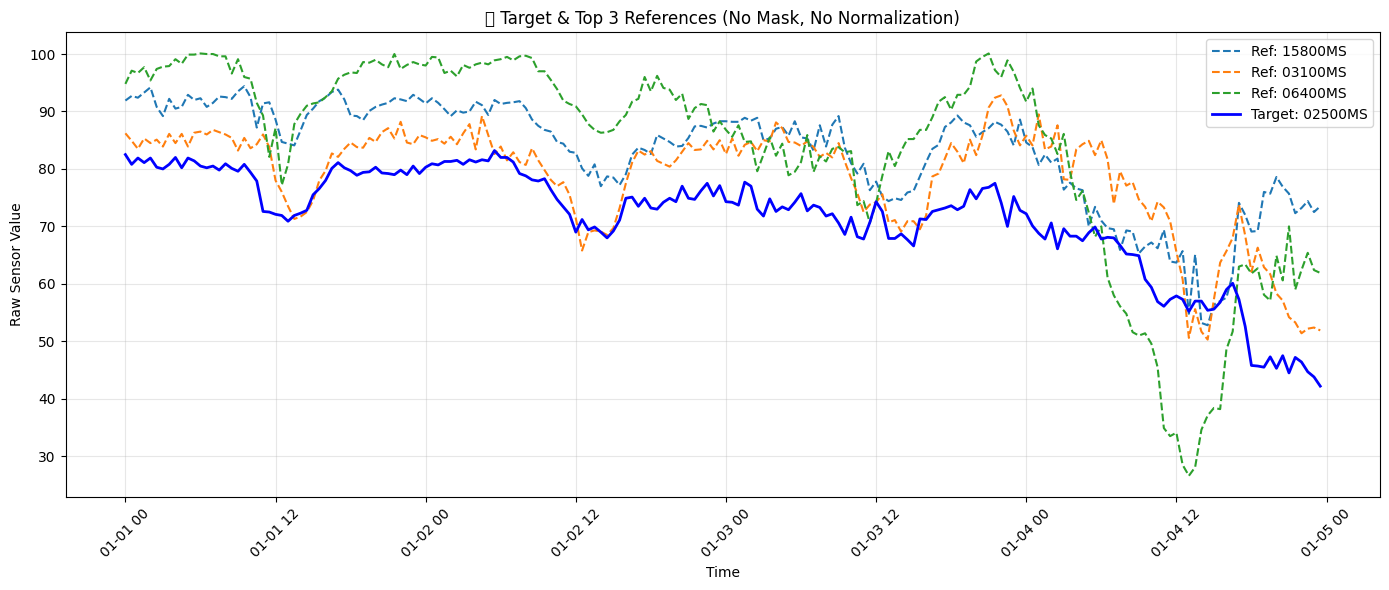

In [ ]:
# Define the stations 
target = "02500MS"
references = ["15800MS","03100MS","06400MS"]

# Define time range for plot (e.g., Jan 1 to Jan 4, 2023)
start_time = "2023-01-01"
end_time = "2023-01-04"

# Slice the DataFrame
plot_df = pattern_df[[target] + references].loc[start_time:end_time].copy()

# Plotting
plt.figure(figsize=(14, 6))

# Plot reference series
for ref in references:
    plt.plot(plot_df.index, plot_df[ref], linestyle='--', label=f"Ref: {ref}")

# Plot target series
plt.plot(plot_df.index, plot_df[target], color='blue', linewidth=2, label=f"Target: {target}")

plt.xlabel("Time")
plt.ylabel("Raw Sensor Value")
plt.title("📍 Target & Top 3 References (No Mask, No Normalization)")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [35]:
pattern_df.isnull().sum()

station_code
02500MS    2
15800MS    2
03100MS    2
06400MS    2
dtype: int64

In [36]:
# Get rows where '02500MS' is NaN
nan_rows = pattern_df[pattern_df['02500MS'].isnull()]
print(nan_rows)

station_code         02500MS  15800MS  03100MS  06400MS
timestamp                                              
2023-02-14 14:00:00      NaN      NaN      NaN      NaN
2023-02-14 14:30:00      NaN      NaN      NaN      NaN


In [37]:
# Check for empty strings in '02500MS'
empty_strings = pattern_df[pattern_df['02500MS'] == ""]
print(empty_strings)

# Check for other placeholders (e.g., "NA")
placeholder_na = pattern_df[pattern_df['02500MS'] == "NA"]
print(placeholder_na)

Empty DataFrame
Columns: [02500MS, 15800MS, 03100MS, 06400MS]
Index: []
Empty DataFrame
Columns: [02500MS, 15800MS, 03100MS, 06400MS]
Index: []


In [38]:
pattern_df = pattern_df.dropna()

In [39]:
pattern_df.isnull().sum()

station_code
02500MS    0
15800MS    0
03100MS    0
06400MS    0
dtype: int64

# -------------------------------------------
# 🔹 STEP 1: Normalize the Time Series Data
# -------------------------------------------

In [ ]:


from sklearn.preprocessing import StandardScaler

# 1️⃣ Initialize the Scaler
scaler = StandardScaler()

# 2️⃣ Fit the scaler on the full pattern_df and transform it
normalized_array = scaler.fit_transform(pattern_df)

# 3️⃣ Reconstruct a DataFrame with the same shape, columns, and index
normalized_df = pd.DataFrame(
    normalized_array,
    columns=pattern_df.columns,
    index=pattern_df.index
)

# 4️⃣ Print shape and preview
print("✅ Normalized shape:", normalized_df.shape)
display(normalized_df.head())


✅ Normalized shape: (14591, 4)


station_code,02500MS,15800MS,03100MS,06400MS
timestamp,,,,
2023-01-01 00:00:00,1.119923,1.189939,0.666856,1.250501
2023-01-01 00:30:00,1.038581,1.225965,0.609234,1.356561
2023-01-01 01:00:00,1.091214,1.212455,0.547179,1.338115
2023-01-01 01:30:00,1.052935,1.252984,0.626964,1.384229
2023-01-01 02:00:00,1.091214,1.293513,0.591504,1.278168


# ---------------------------------------------------------
# 🔹 STEP 2: Define function to inject single-missing in the middle
# ---------------------------------------------------------

In [ ]:


def inject_single_point_middle(series: pd.Series, missing_ratio: float = 0.10, middle_fraction: float = 0.5, random_state: int = 42) -> Tuple[pd.Series, np.ndarray, np.ndarray]:
    """
    Inject NaNs randomly in the middle region of the series (e.g., middle 50%).

    Parameters:
        series (pd.Series): Original complete time series.
        missing_ratio (float): Proportion of points to mask (default = 0.1).
        middle_fraction (float): Fraction of series considered as "middle" (default = 0.5 = 50%).
        random_state (int): Seed for reproducibility.

    Returns:
        masked_series (pd.Series): Series with NaNs injected.
        missing_indices (np.ndarray): Indices where NaNs were inserted.
        true_values (np.ndarray): Original values at those indices.
    """
    ts = series.copy()
    n = len(ts)
    mid_start = int(n * (1 - middle_fraction) / 2)
    mid_end = int(n * (1 + middle_fraction) / 2)

    candidate_indices = np.arange(mid_start, mid_end)
    n_missing = int(len(candidate_indices) * missing_ratio)

    np.random.seed(random_state)
    missing_indices = np.random.choice(candidate_indices, size=n_missing, replace=False)
    true_values = ts.iloc[missing_indices].values

    ts.iloc[missing_indices] = np.nan
    return ts, missing_indices, true_values


# ---------------------------------------------------------
# 🔹 STEP 2b: Apply single_middle_missing to the normalized target series
# ---------------------------------------------------------


In [ ]:

# Define target station 
target_station = "02500MS"

# Apply the masking function for a single missing value in the middle
masked_target, missing_indices, true_vals = inject_single_point_middle(
    normalized_df[target_station], missing_ratio=0.10
)

# ✅ Optional: Print info about the missing point
print("🔢 Injected missing indices:", missing_indices)
print("📉 True values:", true_vals[:5])  # preview first 5
print("🕓 Corresponding timestamps:", normalized_df.index[missing_indices[:5]])


🔢 Injected missing indices: [ 7556  9651  5415  7007  8347  4512 10721  5880  5367  5309  5213  8788
 10911  9111  9995  9930 10066  4410  6944  6301  5836  7592  9653  4844
  4076  7918  7552  5963  8231 10733  5639 10887  4201  5552  5681  4862
  5262  4649  6035  9648  5180  8973  6411 10349  4143  6338 10860  9047
  9578  4475  7199  3708  5076  6617  7602  7768  7197  8836  4112  9283
 10598  7877  9792  5549  3832  6309  4579 10132  9157  5134  4731 10770
  9382  6586  5587  9128  6915  5350 10028  6891  8085  9196  7710  8916
 10738  6365  5387  8670  7641  3748  8152  4383 10758  4185  8167  8800
  4380  8865  3726  9455  6760  8925  6729  8586  3779  4384  4688  5742
 10846 10495  5281 10072  9174  9890 10254  6955  8373  8888  8759  6294
  6786  8886  3966  9504 10545  4489  5541  3824  8810  8318  7479  7608
  5156 10301  5824  7318  5402  5892  6840  4685 10206  7097  9091  7080
  6649  6163  7345  5692  7886  8357  5375  6966  9019  6418  8199  7026
  7504  9082  7751 1043

# ---------------------------------------------------------
# 🔹 STEP 3: Prepare NumPy arrays for imputation and evaluation
# ---------------------------------------------------------

In [ ]:


# 1️⃣ Extract the reference station names (excluding the target)
reference_stations = [col for col in normalized_df.columns if col != target_station]

# 2️⃣ Get reference matrix as shape (num_refs, time) — transposed
ref_matrix = normalized_df[reference_stations].to_numpy().T  # shape: (num_refs, time)

# 3️⃣ Get the masked target series as array (shape: time,)
masked_target_array = masked_target.to_numpy().copy()

# 4️⃣ Get the original (true) unmasked target series
true_target_array = normalized_df[target_station].to_numpy()

# 5️⃣ Get the indices of missing values
missing_indices = np.where(np.isnan(masked_target_array))[0]
true_vals = true_target_array[missing_indices]

# ✅ Preview shapes and sanity check
print("🎯 Target shape:", masked_target_array.shape)
print("📘 Ref matrix shape:", ref_matrix.shape)
print("❓ Missing indices (preview):", missing_indices[:5])
print("🔍 True values at missing indices (preview):", true_vals[:5])


🎯 Target shape: (14591,)
📘 Ref matrix shape: (3, 14591)
❓ Missing indices (preview): [3664 3666 3678 3684 3688]
🔍 True values at missing indices (preview): [ 0.19644577  0.00983632 -0.68875289 -0.33945828 -0.349028  ]


# -----------------------------------------------
# 🔹 STEP 4.1: Set safe parameters for all models
# -----------------------------------------------

In [ ]:


k = 5  # Number of top matching sequences (for TKCM-based methods)
l = 7  # Sliding window size for pattern matching (should be ≤ sequence length)

# 🧠 For matrix factorization-based methods (e.g., SVD, TRMF)
# Set a safe low-rank approximation based on the number of reference series
num_references = ref_matrix.shape[0]
rank = max(1, min(num_references - 1, 5))  # You can increase 2 → 5 for better modeling if safe


### --- Basic Imputers ---


In [45]:
from sklearn.impute import SimpleImputer

# --- Basic Imputers ---

class ZeroImputer:
    def fit_transform(self, X):
        X = X.copy()
        X[np.isnan(X)] = 0
        return X


class MinImputer:
    def fit_transform(self, X):
        fill_value = np.nanmin(X[~np.isnan(X)])
        imp = SimpleImputer(strategy='constant', fill_value=fill_value)
        return imp.fit_transform(X)

class InterpolationImputer:
    def fit_transform(self, X):
        return pd.DataFrame(X).interpolate(method='linear', axis=0, limit_direction='both').values


# -----------------------------------------------
# 🔹 STEP 4.2: Apply each model with correct usage
# -----------------------------------------------

In [ ]:


# Stack the masked target (first row) + full reference matrix (rest)
X_stacked = np.vstack([masked_target_array, ref_matrix])  # Shape: (1 + num_refs, time)

# -------------------
# TKCM-based Methods
# -------------------

# 1️⃣ TKCM
tkcm_imputed = masked_target_array.copy()
tkcm_model = TKCM(k=k, l=l)
for offset in missing_indices:
    tkcm_imputed = tkcm_model.impute(tkcm_imputed, offset=offset, ref_ts=ref_matrix)

# 2️⃣ TKCM_PLUS
tkcm_plus_imputed = masked_target_array.copy()
tkcm_plus_model = TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.1)
for offset in missing_indices:
    tkcm_plus_imputed = tkcm_plus_model.impute(tkcm_plus_imputed, offset=offset, ref_ts=ref_matrix)

# 3️⃣ TKCM_Weighted
tkcm_weighted_imputed = masked_target_array.copy()
tkcm_weighted_model = TKCM_Weighted(k=k, l=l)
for offset in missing_indices:
    tkcm_weighted_imputed = tkcm_weighted_model.impute(tkcm_weighted_imputed, offset=offset, ref_ts=ref_matrix)

# 4️⃣ TKCM_PRO
tkcm_pro_imputed = masked_target_array.copy()
tkcm_pro_model = TKCM_PRO(k=k, l=l)
for offset in missing_indices:
    tkcm_pro_imputed = tkcm_pro_model.impute(tkcm_pro_imputed, offset=offset, ref_ts=ref_matrix)

# --------------------------
# Matrix Factorization Models
# --------------------------

# 5️⃣ CDRec
cdrec = CDRec(rank=rank)
cdrec_imputed = cdrec.impute(X_stacked.copy())[0]  # Only return target row

# 6️⃣ DynaMMo
dynammo = DynaMMo(latent_dim=rank)
dynammo_imputed = dynammo.fit_transform(X_stacked.copy())[0]

# 7️⃣ SoftImpute
soft = SoftImpute(max_rank=rank)
soft_imputed = soft.fit_transform(X_stacked.copy())[0]

# 8️⃣ IterativeSVD
svd = IterativeSVD(rank=rank)
svd_imputed = svd.fit_transform(X_stacked.copy())[0]

# 9️⃣ ST_MVL
st_mvl = ST_MVL()
st_mvl_imputed = st_mvl.impute(X_stacked.copy())[0]

# 🔟 TRMF
trmf = TRMFImputer(rank=rank)
trmf_imputed = trmf.fit_transform(X_stacked.copy())[0]

# --------------------
# Simple Baseline Models
# --------------------

# 1️⃣1️⃣ Zero Imputer
zero_imputer = ZeroImputer()
zero_imputed = zero_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣2️⃣ Min Imputer
min_imputer = MinImputer()
min_imputed = min_imputer.fit_transform(X_stacked.copy())[0]

# 1️⃣3️⃣ Interpolation Imputer
interp_imputer = InterpolationImputer()
interp_imputed = interp_imputer.fit_transform(X_stacked.copy())[0]


In [47]:

results_point = []

# ✅ New helper to evaluate predictions at multiple missing indices
def evaluate_pointwise(name, imputed_array, true_values, missing_indices):
    try:
        predicted_vals = imputed_array[missing_indices]
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("Contains NaN")
        
        errors = predicted_vals - true_values
        mae = np.mean(np.abs(errors))
        rmse = np.sqrt(np.mean(errors ** 2))
        
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4)
        })
    
    except Exception as e:
        print(f"❌ {name} failed: {e}")
        results_point.append({
            "Method": name,
            "Missing Points": len(missing_indices),
            "MAE": "NaN",
            "RMSE": "NaN"
        })


In [48]:
# Step 1: Stack masked target + reference
X_stmv = np.vstack([masked_target_array, ref_matrix])

# Step 2: Remove NaNs in references (only in reference rows)
X_stmv[1:, :] = np.nan_to_num(X_stmv[1:, :])

# Step 3: Run ST_MVL and evaluate at missing indices
try:
    st_mvl_model = ST_MVL()
    st_mvl_imputed = st_mvl_model.impute(X_stmv)[0]  # Only take imputed target row
    evaluate_pointwise("ST_MVL", st_mvl_imputed, true_vals, missing_indices)
except Exception as e:
    print("❌ ST_MVL failed:", e)
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("ST_MVL", fallback, true_vals, missing_indices)



In [49]:
# Step 1: Prep TRMF input (shape = time x features)
X_trmf_input = np.vstack([masked_target_array, ref_matrix]).T.copy()

# Step 2: Generate mask and fill missing
observed_mask = ~np.isnan(X_trmf_input)
X_trmf_input = np.nan_to_num(X_trmf_input, nan=0.0).astype(np.float64)

# Step 3: Fit & transform
try:
    trmf_model = TRMFImputer(rank=rank, lag_idx=[1, 2, 3])
    trmf_model.fit(X_trmf_input, observed_mask)
    X_trmf_output = trmf_model.transform()

    trmf_imputed = X_trmf_output[:, 0]  # First column is the target
    evaluate_pointwise("TRMF", trmf_imputed, true_vals, missing_indices)

except Exception as e:
    print("❌ TRMF failed:", e)
    fallback = np.full_like(masked_target_array, np.nan)
    evaluate_pointwise("TRMF", fallback, true_vals, missing_indices)


In [50]:
# ✅ TKCM Variants — loop over all, support multiple missing
for method_name, model in {
    "TKCM": TKCM(k=k, l=l),
    "TKCM_PLUS": TKCM_PLUS(k=k, l=l, alpha=0.5, beta=0.5),
    "TKCM_Weighted": TKCM_Weighted(k=k, l=l),
    "TKCM_PRO": TKCM_PRO(k=k, l=l),
}.items():
    try:
        # Impute once for all missing values (if supported)
        imputed_array = masked_target_array.copy()
        for offset in missing_indices:
            imputed_array = model.impute(imputed_array, offset=offset, ref_ts=ref_matrix)

        evaluate_pointwise(method_name, imputed_array, true_vals, missing_indices)

    except Exception as e:
        print(f"❌ {method_name} failed:", e)
        fallback = np.full_like(masked_target_array, np.nan)
        evaluate_pointwise(method_name, fallback, true_vals, missing_indices)

# ✅ Baseline Models (already computed externally)
baseline_models = {
    "CDRec": cdrec_imputed,
    "DynaMMo": dynammo_imputed,
    "SoftImpute": soft_imputed,
    "SVDImpute": svd_imputed,
    "Zero": zero_imputed,
    "Min": min_imputed,
    "Interpolation": interp_imputed,
    "ST_MVL": st_mvl_imputed,
    "TRMF": trmf_imputed,
}

# ✅ Evaluate all models
for name, imputed_array in baseline_models.items():
    evaluate_pointwise(name, imputed_array, true_vals, missing_indices)

# ✅ Final Results Table
results_df = pd.DataFrame(results_point)
display(results_df.style.background_gradient(cmap="YlGnBu", subset=["MAE", "RMSE"]))


,Method,Missing Points,MAE,RMSE
0,ST_MVL,729,0.436700,0.584400
1,TRMF,729,0.616600,0.747700
2,TKCM,729,0.330900,0.426300
3,TKCM_PLUS,729,0.669300,0.870800
4,TKCM_Weighted,729,0.330200,0.426300
5,TKCM_PRO,729,1.611500,1.842400
6,CDRec,729,0.311400,0.396500
7,DynaMMo,729,0.311300,0.396600
8,SoftImpute,729,0.311900,0.396000
9,SVDImpute,729,0.311300,0.396800


| Rank | Method         | Missing Points | MAE        | RMSE       |
| ---- | -------------- | -------------- | ---------- | ---------- |
| ✅ 1  | **DynaMMo**    | 729            | **0.3113** | 0.3966     |
| ✅ 1  | **SVDImpute**  | 729            | **0.3113** | 0.3968     |
| 3    | SoftImpute     | 729            | 0.3119     | **0.3960** |
| 4    | CDRec          | 729            | 0.3114     | 0.3965     |
| 5    | TKCM\_Weighted | 729            | 0.3302     | 0.4263     |
| 6    | TKCM           | 729            | 0.3309     | 0.4263     |
| 7    | Interpolation  | 729            | 0.4103     | 0.5326     |
| 8    | ST\_MVL        | 729            | 0.4367     | 0.5844     |
| 9    | TKCM\_PLUS     | 729            | 0.6693     | 0.8708     |
| 10   | TRMF           | 729            | 0.6166     | 0.7477     |
| 11   | Zero           | 729            | 0.8723     | 1.0374     |
| 12   | TKCM\_PRO      | 729            | 1.6115     | 1.8424     |
| 13   | Min            | 729            | 2.9071     | 3.0786     |


# ----------------------------------------------------
# 🔍 Grid Search for TKCM and TKCM_Weighted (pointwise)
# ----------------------------------------------------

In [ ]:


k_values = [3, 5, 7, 8, 10, 12]
l_values = [3, 4, 5, 6, 8, 10]

grid_results = []

# Use true_vals and missing_indices from earlier
for method_class, method_name in [
    (TKCM, "TKCM"),
    (TKCM_Weighted, "TKCM_Weighted")
]:
    for k in k_values:
        for l in l_values:
            try:
                imputed = masked_target_array.copy()
                model = method_class(k=k, l=l)
                for offset in missing_indices:
                    imputed = model.impute(imputed, offset=offset, ref_ts=ref_matrix)

                predicted_vals = imputed[missing_indices]
                if np.any(np.isnan(predicted_vals)):
                    raise ValueError("NaN in imputed values")

                mae = np.mean(np.abs(predicted_vals - true_vals))
                rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

                grid_results.append({
                    "Method": method_name,
                    "k": k,
                    "l": l,
                    "MAE": round(mae, 4),
                    "RMSE": round(rmse, 4)
                })

            except Exception as e:
                grid_results.append({
                    "Method": method_name,
                    "k": k,
                    "l": l,
                    "MAE": "ERROR",
                    "RMSE": "ERROR"
                })

# --------------------------------------------------
# 📊 Convert to DataFrame and Show Best Configs
# --------------------------------------------------

grid_df = pd.DataFrame(grid_results)
grid_df_clean = grid_df[(grid_df["MAE"] != "ERROR") & (grid_df["RMSE"] != "ERROR")].copy()
grid_df_clean[["MAE", "RMSE"]] = grid_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# ✅ Show sorted by MAE
display(grid_df_clean.sort_values(by=["MAE", "RMSE"]).style.set_caption("Grid Search Results (Pointwise Imputation)"))


,Method,k,l,MAE,RMSE
30,TKCM,12,3,0.297000,0.386300
66,TKCM_Weighted,12,3,0.298000,0.387600
67,TKCM_Weighted,12,4,0.300100,0.388200
61,TKCM_Weighted,10,4,0.300500,0.389500
24,TKCM,10,3,0.300600,0.391000
31,TKCM,12,4,0.300800,0.388600
25,TKCM,10,4,0.300900,0.389700
19,TKCM,8,4,0.300900,0.392100
55,TKCM_Weighted,8,4,0.301500,0.392600
68,TKCM_Weighted,12,5,0.302000,0.393900


| Rank | Method         | k  | l | MAE        | RMSE       |
| ---- | -------------- | -- | - | ---------- | ---------- |
| ✅ 1  | **TKCM**       | 12 | 3 | **0.2970** | **0.3863** |
| 2    | TKCM\_Weighted | 12 | 3 | 0.2980     | 0.3876     |
| 3    | TKCM\_Weighted | 12 | 4 | 0.3001     | 0.3882     |
| 4    | TKCM\_Weighted | 10 | 4 | 0.3005     | 0.3895     |


In [52]:
#  Get Best Configs for Each Model

best_tkcm = grid_df_clean[grid_df_clean["Method"] == "TKCM"].nsmallest(1, "MAE")
best_weighted = grid_df_clean[grid_df_clean["Method"] == "TKCM_Weighted"].nsmallest(1, "MAE")

print("✅ Best TKCM:", best_tkcm[["k", "l", "MAE", "RMSE"]].values[0])
print("✅ Best TKCM_Weighted:", best_weighted[["k", "l", "MAE", "RMSE"]].values[0])


✅ Best TKCM: [12.      3.      0.297   0.3863]
✅ Best TKCM_Weighted: [12.      3.      0.298   0.3876]


# -----------------------------------------
# 🔍 Grid Search for TKCM_PLUS (α, β combos)
# -----------------------------------------


In [ ]:

alphas = [0.2, 0.5, 0.8]
betas = [0.2, 0.5, 0.8]

# Only include combinations where α + β ≈ 1 (tolerance = 0.1)
valid_combinations = [(a, b) for a in alphas for b in betas if abs(a + b - 1.0) <= 0.1]

# Store results here
plus_grid_results = []

# Loop over (α, β) combinations
for alpha, beta in tqdm(valid_combinations, desc="Searching (α, β)", unit="combo"):
    try:
        imputed = masked_target_array.copy()
        model = TKCM_PLUS(k=k, l=l, alpha=alpha, beta=beta)
        for offset in missing_indices:
            imputed = model.impute(imputed, offset=offset, ref_ts=ref_matrix)

        predicted_vals = imputed[missing_indices]
        if np.any(np.isnan(predicted_vals)):
            raise ValueError("NaN in imputed values")

        mae = np.mean(np.abs(predicted_vals - true_vals))
        rmse = np.sqrt(np.mean((predicted_vals - true_vals) ** 2))

        plus_grid_results.append({
            "Method": f"TKCM_PLUS α={alpha}, β={beta}",
            "Alpha": alpha,
            "Beta": beta,
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "Missing Points": len(missing_indices)
        })

    except Exception as e:
        plus_grid_results.append({
            "Method": f"TKCM_PLUS α={alpha}, β={beta}",
            "Alpha": alpha,
            "Beta": beta,
            "MAE": "ERROR",
            "RMSE": "ERROR",
            "Missing Points": len(missing_indices)
        })

# Convert to DataFrame
plus_df = pd.DataFrame(plus_grid_results)

# Clean and sort
plus_df_clean = plus_df[plus_df["RMSE"] != "ERROR"].copy()
plus_df_clean[["MAE", "RMSE"]] = plus_df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

# Display best α–β configs
display(plus_df_clean.sort_values(by=["MAE", "RMSE"]).style.set_caption("TKCM_PLUS α–β Search Results"))


Searching (α, β): 100%|██████████| 3/3 [23:27<00:00, 469.22s/combo]


,Method,Alpha,Beta,MAE,RMSE,Missing Points
2,"TKCM_PLUS α=0.8, β=0.2",0.800000,0.200000,0.432800,0.599700,729
1,"TKCM_PLUS α=0.5, β=0.5",0.500000,0.500000,0.536200,0.714300,729
0,"TKCM_PLUS α=0.2, β=0.8",0.200000,0.800000,0.666500,0.845200,729


In [54]:
# Best Config Extraction 
best_plus = plus_df_clean.nsmallest(1, "MAE")
print("✅ Best TKCM_PLUS config:", best_plus[["Alpha", "Beta", "MAE", "RMSE"]].values[0])


✅ Best TKCM_PLUS config: [0.8    0.2    0.4328 0.5997]


In [55]:
def run_tkcm_pro_robust_real(k_vals, threshold, masked_target_array, true_target_array, ref_matrix, missing_indices, true_vals):
    results = []

    for k in k_vals:
        try:
            # Step 1: Pearson similarity with target
            pearson_corrs = [np.corrcoef(true_target_array, ref)[0, 1] for ref in ref_matrix]
            selected_indices = [i for i, corr in enumerate(pearson_corrs) if corr >= threshold]

            # Step 2: Filter reference matrix
            filtered_refs = ref_matrix[selected_indices, :] if selected_indices else ref_matrix[:1, :]

            # Step 3: Impute by anchor averaging
            imputed = masked_target_array.copy()
            for offset in missing_indices:
                values = filtered_refs[:, offset]
                if np.all(np.isnan(values)):
                    continue
                imputed[offset] = np.nanmean(values)

            # Step 4: Evaluate
            predicted = imputed[missing_indices]
            mae = np.mean(np.abs(predicted - true_vals))
            rmse = np.sqrt(np.mean((predicted - true_vals) ** 2))

            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": len(selected_indices),
                "MAE": round(mae, 4),
                "RMSE": round(rmse, 4)
            })

        except Exception as e:
            results.append({
                "Method": "TKCM_PRO_Robust",
                "k": k,
                "Threshold": threshold,
                "Anchors Used": "ERROR",
                "MAE": "ERROR",
                "RMSE": "ERROR"
            })

    df = pd.DataFrame(results)
    df_clean = df[df["MAE"] != "ERROR"].copy()
    df_clean[["MAE", "RMSE"]] = df_clean[["MAE", "RMSE"]].apply(pd.to_numeric)

    return df_clean.sort_values(by=["MAE", "RMSE"])


In [56]:
k_values = [3, 5, 7, 9, 12]
threshold = 0.7  # or try 0.8, 0.9

tkcm_pro_robust_df = run_tkcm_pro_robust_real(
    k_vals=k_values,
    threshold=threshold,
    masked_target_array=masked_target_array,
    true_target_array=true_target_array,
    ref_matrix=ref_matrix,
    missing_indices=missing_indices,
    true_vals=true_vals
)

display(tkcm_pro_robust_df.style.set_caption("✅ TKCM_PRO Robustified Results"))


,Method,k,Threshold,Anchors Used,MAE,RMSE
0,TKCM_PRO_Robust,3,0.700000,3,0.309600,0.398900
1,TKCM_PRO_Robust,5,0.700000,3,0.309600,0.398900
2,TKCM_PRO_Robust,7,0.700000,3,0.309600,0.398900
3,TKCM_PRO_Robust,9,0.700000,3,0.309600,0.398900
4,TKCM_PRO_Robust,12,0.700000,3,0.309600,0.398900


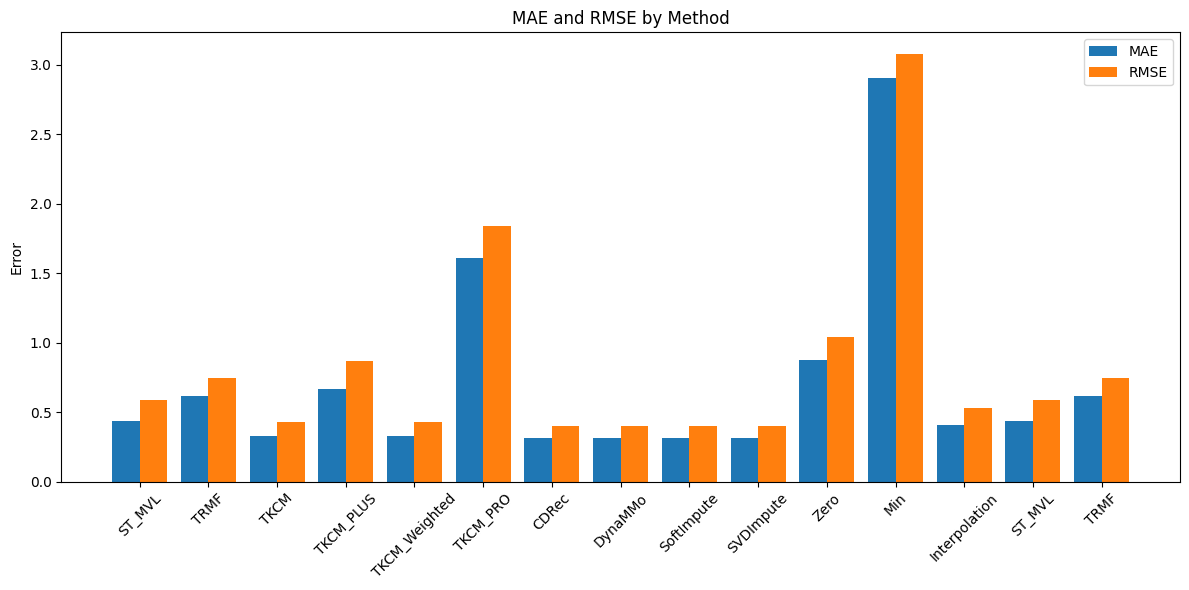

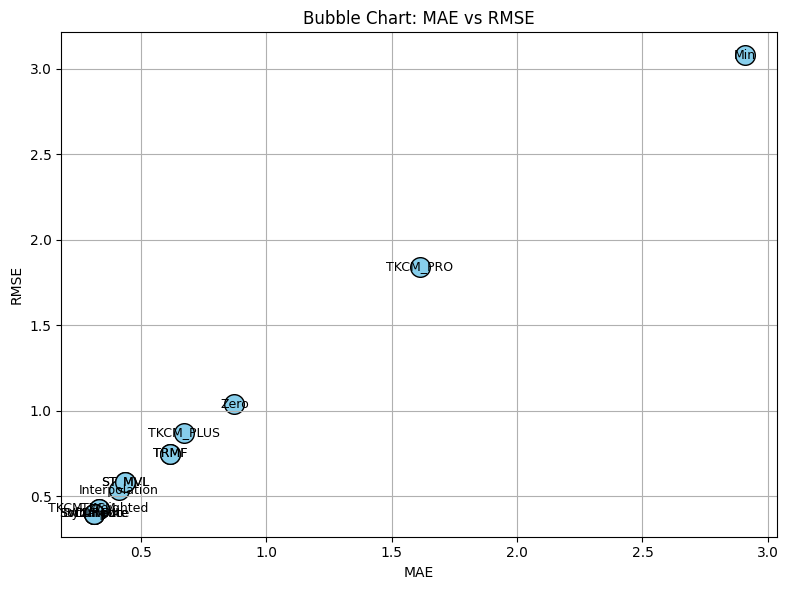

In [63]:
# Convert results_point to DataFrame for plotting
results_df = pd.DataFrame(results_point)

# Filter out methods with valid numeric values
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# ------------------------
# 📊 Bar Plot: MAE & RMSE
# ------------------------
fig, ax = plt.subplots(figsize=(12, 6))
bar_width = 0.4
x = range(len(plot_df))

ax.bar([i - bar_width/2 for i in x], plot_df["MAE"], width=bar_width, label="MAE")
ax.bar([i + bar_width/2 for i in x], plot_df["RMSE"], width=bar_width, label="RMSE")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["Method"], rotation=45)
ax.set_ylabel("Error")
ax.set_title("MAE and RMSE by Method")
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------
# 🔵 Bubble Plot: MAE vs RMSE
# -----------------------------
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(plot_df["MAE"], plot_df["RMSE"],
                     s=200, c='skyblue', edgecolors='black')

# Annotate each point
for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9,
                ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Bubble Chart: MAE vs RMSE")
plt.grid(True)
plt.tight_layout()
plt.show()


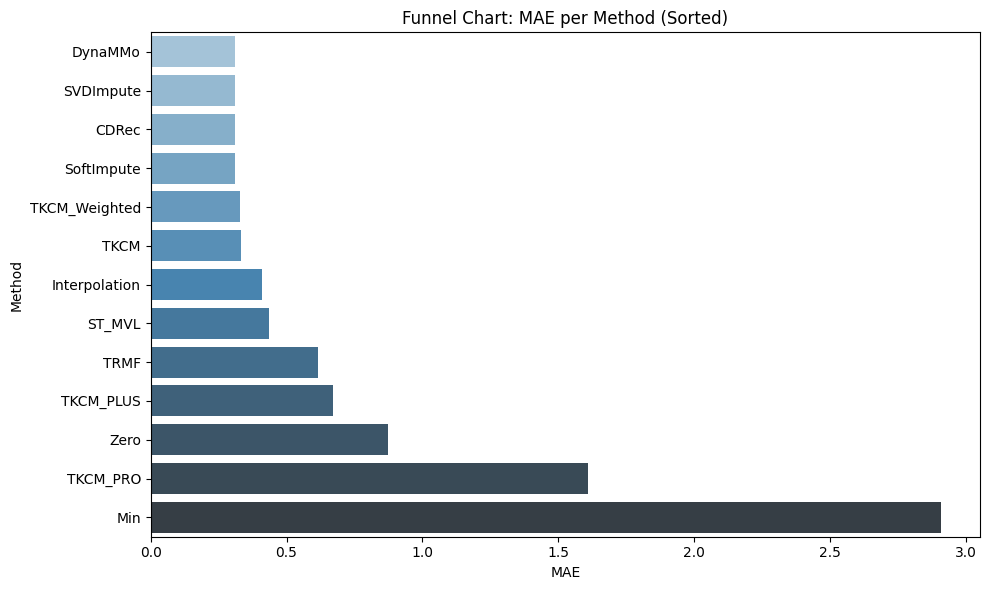

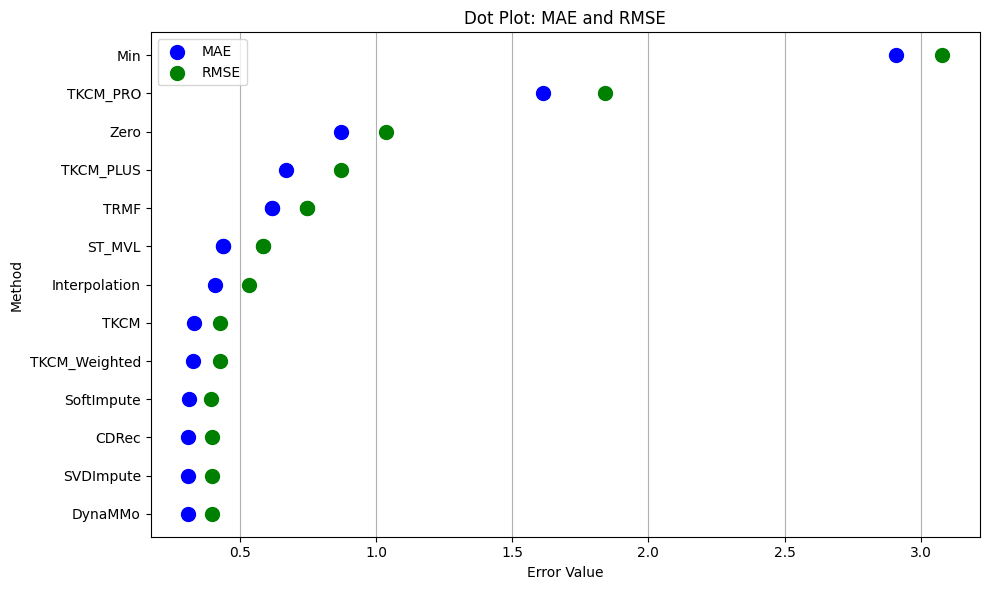

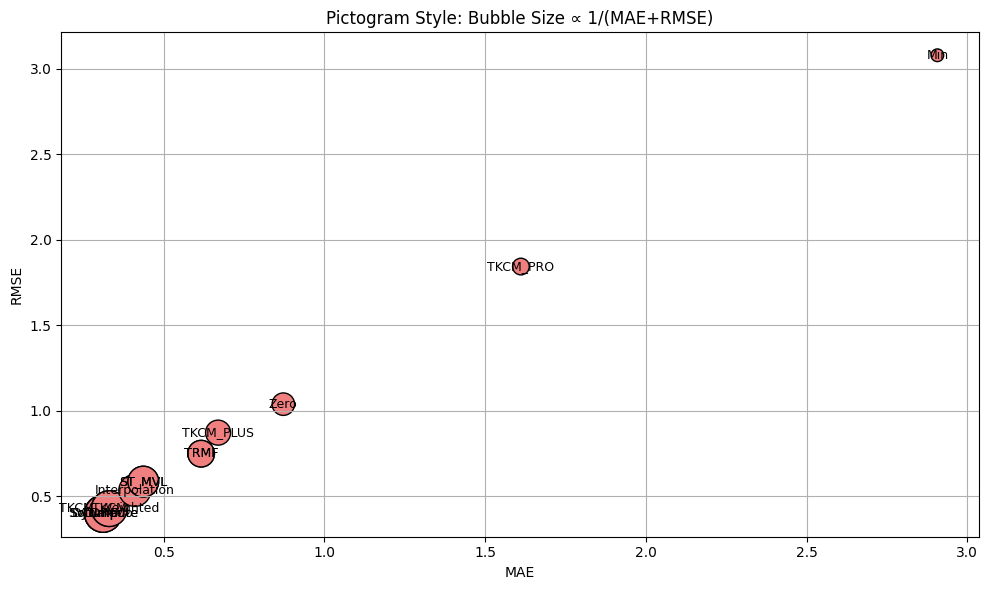

In [64]:
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Use existing plot_df from previous context
plot_df = results_df[(results_df["MAE"] != "NaN") & (results_df["RMSE"] != "NaN")].copy()
plot_df["MAE"] = plot_df["MAE"].astype(float)
plot_df["RMSE"] = plot_df["RMSE"].astype(float)

# Sort by MAE for consistent plotting
plot_df = plot_df.sort_values("MAE").reset_index(drop=True)

# --------------------------------------
# 📉 Funnel Plot: Sorted MAE per Method
# --------------------------------------
plt.figure(figsize=(10, 6))
sns.barplot(x="MAE", y="Method", data=plot_df, palette="Blues_d")
plt.title("Funnel Chart: MAE per Method (Sorted)")
plt.xlabel("MAE")
plt.ylabel("Method")
plt.tight_layout()
plt.show()

# ------------------------------
# 🎯 Dot Plot: MAE & RMSE Values
# ------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(plot_df["MAE"], plot_df["Method"], label="MAE", color="blue", s=100)
plt.scatter(plot_df["RMSE"], plot_df["Method"], label="RMSE", color="green", s=100)
plt.xlabel("Error Value")
plt.ylabel("Method")
plt.title("Dot Plot: MAE and RMSE")
plt.legend()
plt.grid(True, axis='x')
plt.tight_layout()
plt.show()

# ---------------------------------
# 📦 Pictogram: Bubble-like Visual
# ---------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
sizes = 500 / (plot_df["MAE"] + plot_df["RMSE"])  # Inverse error = bigger is better

ax.scatter(plot_df["MAE"], plot_df["RMSE"], s=sizes, color='lightcoral', edgecolors='black')

for i, row in plot_df.iterrows():
    ax.annotate(row["Method"], (row["MAE"], row["RMSE"]), fontsize=9, ha='center', va='center')

ax.set_xlabel("MAE")
ax.set_ylabel("RMSE")
ax.set_title("Pictogram Style: Bubble Size ∝ 1/(MAE+RMSE)")
plt.grid(True)
plt.tight_layout()
plt.show()


### Comparison of imputation methods

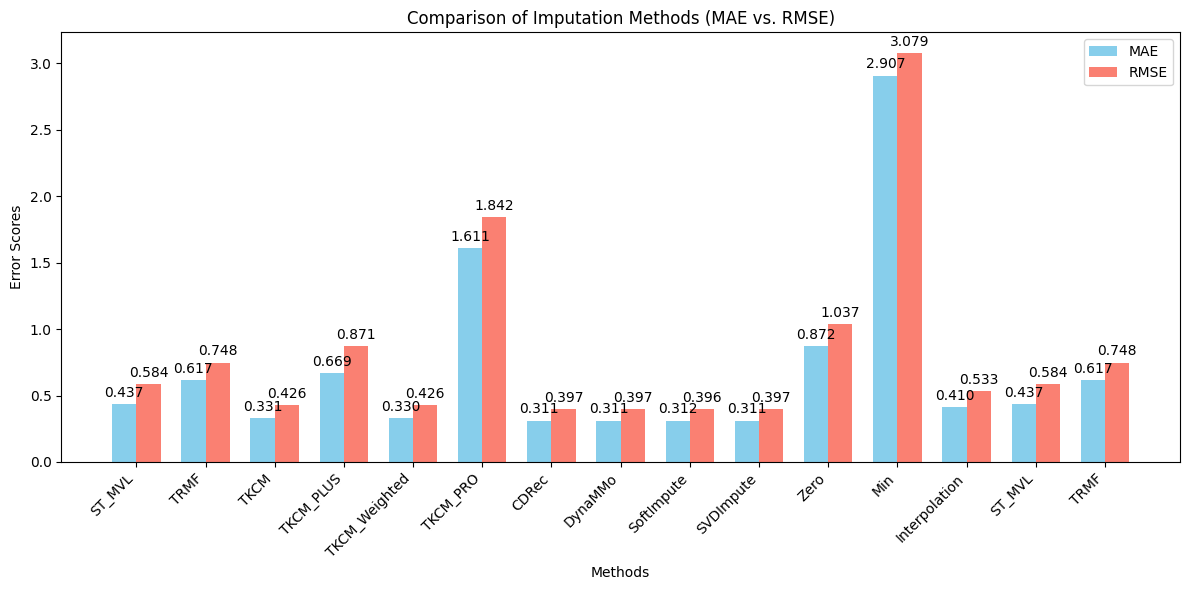

In [65]:

# Assuming results_df is already computed
methods = results_df["Method"]
mae_scores = results_df["MAE"]
rmse_scores = results_df["RMSE"]

x = np.arange(len(methods))  # X-axis positions
width = 0.35  # Bar width

# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot MAE bars
mae_bars = ax.bar(x - width/2, mae_scores, width, label='MAE', color='skyblue')

# Plot RMSE bars
rmse_bars = ax.bar(x + width/2, rmse_scores, width, label='RMSE', color='salmon')

# Add labels, title, and legend
ax.set_xlabel('Methods')
ax.set_ylabel('Error Scores')
ax.set_title('Comparison of Imputation Methods (MAE vs. RMSE)')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()

# Add value labels on top of bars
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(mae_bars)
add_labels(rmse_bars)

# Adjust layout to prevent clipping
plt.tight_layout()

# Show plot
plt.show()